# Daily and weekly sales distributions FCM

This notebook gives a compact overview of the processed demand series at their native aggregation levels. Each aggregation is analysed for both the regular dataset and the FCM dataset.

For the daily FCM analysis, the notebook uses `data/interim/transactions_dst_daily_no_tail_fcm`, created by `src/data/preparation/filter_no_late_demand.py`. That dataset is already filtered for its overall minimum number of demand periods and for late-demand tails, so no additional global minimum-demand filter is applied here. The later `DEFAULT_MIN_TRAIN_SIZE` checks still test whether enough positive demand exists inside a candidate training window.

The unit of analysis is an `ARTIKEL_ID` x `MARKT_ID` series. A period is active when a row exists; a demand period has positive `ABVERKAUFTE_MENGE_KG`. The weekly data additionally contains the number of active, demand, and zero-sales days in each week.

In [73]:
from pathlib import Path
from io import BytesIO
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
import matplotlib
matplotlib.use("Agg")
import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Image
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
GROUP_COLS = ["ARTIKEL_ID", "MARKT_ID"]
DEMAND_COL = "ABVERKAUFTE_MENGE_KG"
PROJECT_ROOT = next((p.resolve() for p in [Path("../.."), Path(".."), Path(".")] if (p / "src").exists()), None)
if PROJECT_ROOT is None: raise FileNotFoundError("Could not find the project root containing src/.")
PROCESSED_DATA_ROOT = next((p for p in [Path("../../data/processed"), Path("../data/processed"), Path("data/processed")] if p.exists()), None)
INTERIM_DATA_ROOT = next((p for p in [Path("../../data/interim"), Path("../data/interim"), Path("data/interim")] if p.exists()), None)
if PROCESSED_DATA_ROOT is None: raise FileNotFoundError("Could not find data/processed from the notebook directory.")
if INTERIM_DATA_ROOT is None: raise FileNotFoundError("Could not find data/interim from the notebook directory.")
DATA_ROOT = PROCESSED_DATA_ROOT
DATASETS = {
    "daily": {
        "regular": DATA_ROOT / "transactions_dst_over_days",
        "fcm": INTERIM_DATA_ROOT / "transactions_dst_daily_no_tail_fcm",
    },
    "weekly": {
        "regular": DATA_ROOT / "transactions_dst_over_weeks",
        "fcm": DATA_ROOT / "transactions_dst_over_weeks_fcm",
    },
}
for aggregation in DATASETS:
    for variant, path in DATASETS[aggregation].items():
        if not list(path.glob("*.parquet")): raise FileNotFoundError(f"No parquet files found in {path}")
con = duckdb.connect()
con.execute("PRAGMA threads=4")


## Analysis helpers

The summaries below are generated with one function so daily and weekly results use the same definitions. The weekly `demand_day_share` is the share of active open days with positive sales, while `demand_period_share` is the share of active weeks with positive weekly demand.


In [74]:
def load_series_metrics(aggregation, variant, data_dir):
    path = str(data_dir / "*.parquet")
    if aggregation == "daily":
        query = f"""
        WITH rows AS (
            SELECT ARTIKEL_ID, MARKT_ID, CAST(COALESCE({DEMAND_COL}, 0) AS DOUBLE) AS demand, CAST(DATE AS DATE) AS period
            FROM read_parquet(?)
        )
        SELECT ARTIKEL_ID, MARKT_ID, COUNT(*)::INTEGER AS active_periods,
               SUM((demand > 0)::INTEGER)::INTEGER AS demand_periods,
               SUM((demand <= 0)::INTEGER)::INTEGER AS zero_periods,
               SUM(demand) AS total_demand, MIN(period) AS first_period, MAX(period) AS last_period,
               NULL::DOUBLE AS demand_day_share
        FROM rows GROUP BY ARTIKEL_ID, MARKT_ID
        """
    else:
        query = f"""
        SELECT ARTIKEL_ID, MARKT_ID, COUNT(*)::INTEGER AS active_periods,
               SUM((COALESCE({DEMAND_COL}, 0) > 0)::INTEGER)::INTEGER AS demand_periods,
               SUM((COALESCE({DEMAND_COL}, 0) <= 0)::INTEGER)::INTEGER AS zero_periods,
               SUM(COALESCE({DEMAND_COL}, 0)) AS total_demand,
               MIN(CAST(DATE AS DATE)) AS first_period, MAX(CAST(DATE AS DATE)) AS last_period,
               SUM(COALESCE(demand_days_in_week, 0)) / NULLIF(SUM(COALESCE(active_days_in_week, 0)), 0) AS demand_day_share
        FROM read_parquet(?) GROUP BY ARTIKEL_ID, MARKT_ID
        """
    result = con.execute(query, [path]).fetchdf()
    result["aggregation"], result["variant"] = aggregation, variant
    result["demand_period_share"] = result["demand_periods"] / result["active_periods"]
    if aggregation == "daily": result["demand_day_share"] = result["demand_period_share"]
    result["zero_period_share"] = result["zero_periods"] / result["active_periods"]
    result["dataset"] = aggregation.title() + " / " + variant.title()
    return result

metrics = pd.concat([load_series_metrics(a, v, p) for a, variants in DATASETS.items() for v, p in variants.items()], ignore_index=True)
DATASET_ORDER = ["Daily / Regular", "Daily / Fcm", "Weekly / Regular", "Weekly / Fcm"]
metrics["dataset"] = pd.Categorical(metrics["dataset"], categories=DATASET_ORDER, ordered=True)
metrics.head()


,ARTIKEL_ID,MARKT_ID,active_periods,demand_periods,zero_periods,total_demand,first_period,last_period,demand_day_share,aggregation,variant,demand_period_share,zero_period_share,dataset
0,294984,1300002,1521,1338,183,504.350,2021-07-12,2026-07-10,0.879684,daily,regular,0.879684,0.120316,Daily / Regular
1,316676,1350009,1521,917,604,1244.285,2021-07-12,2026-07-10,0.602893,daily,regular,0.602893,0.397107,Daily / Regular
2,954019,1300008,1521,1187,334,410.230,2021-07-12,2026-07-10,0.780408,daily,regular,0.780408,0.219592,Daily / Regular
3,591245,1100011,1512,158,1354,38.160,2021-07-22,2026-07-10,0.104497,daily,regular,0.104497,0.895503,Daily / Regular
4,308273,1300024,1521,1064,457,620.509,2021-07-12,2026-07-10,0.699540,daily,regular,0.699540,0.300460,Daily / Regular


# Daily analysis

Daily rows represent the active open-day periods created by the data preparation pipeline.


In [75]:
daily = metrics[metrics["aggregation"] == "daily"].copy()
daily_overview = (daily.groupby("dataset", observed=True).agg(series=("ARTIKEL_ID", "size"), stores=("MARKT_ID", "nunique"), products=("ARTIKEL_ID", "nunique"), active_days=("active_periods", "sum"), demand_days=("demand_periods", "sum"), zero_days=("zero_periods", "sum"), total_demand_kg=("total_demand", "sum")).reset_index())
daily_overview["demand_day_share"] = daily_overview["demand_days"] / daily_overview["active_days"]
display(daily_overview.style.format({"total_demand_kg":"{:,.1f}", "demand_day_share":"{:.1%}"}))


,dataset,series,stores,products,active_days,demand_days,zero_days,total_demand_kg,demand_day_share
0,Daily / Regular,152550,112,3570,165390399,25236647,140153752,"29,690,343.2",15.3%
1,Daily / Fcm,2092,104,31,518591,189936,328655,"93,212.7",36.6%


,dataset,measure,p25,median,p75,p95
0,Daily / Regular,active_periods,718.00,1311.00,1512.00,1521.00
1,Daily / Regular,demand_periods,7.00,29.00,175.00,864.00
2,Daily / Regular,zero_periods,497.00,1039.00,1357.00,1487.00
3,Daily / Regular,demand_day_share,0.01,0.04,0.19,0.65
4,Daily / Fcm,active_periods,165.00,247.00,331.00,357.00
5,Daily / Fcm,demand_periods,27.00,62.00,136.00,260.45
6,Daily / Fcm,zero_periods,87.00,158.00,213.00,279.45
7,Daily / Fcm,demand_day_share,0.15,0.30,0.53,0.80


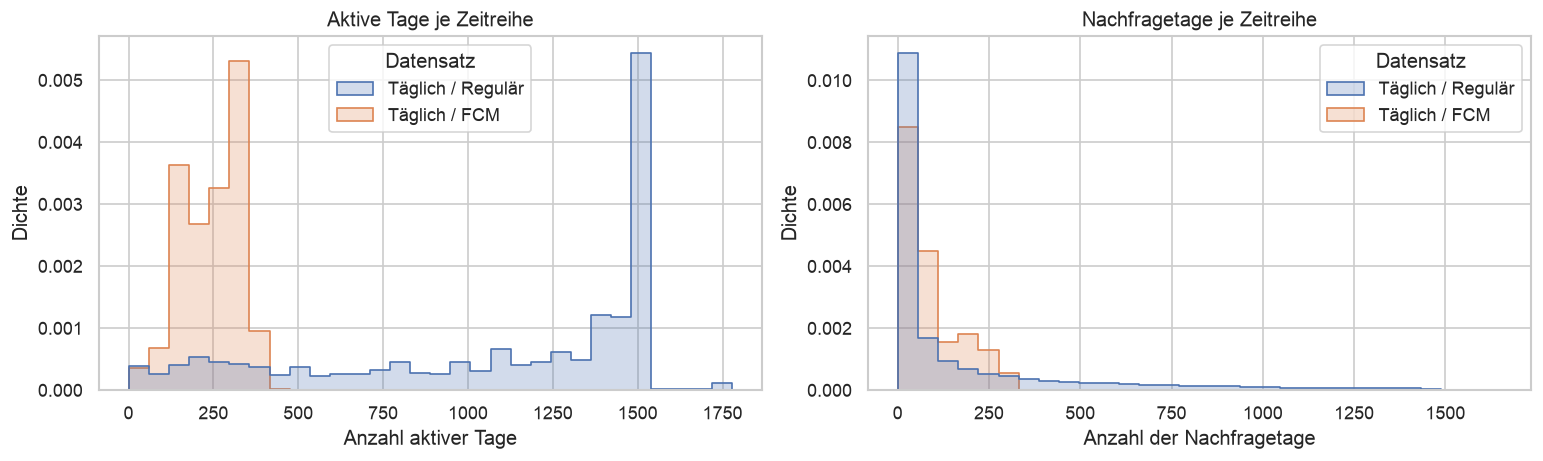

In [76]:
def distribution_table(frame, columns):
    rows = []
    for dataset, group in frame.groupby("dataset", observed=True):
        for column in columns:
            q = group[column].dropna().quantile([.25, .5, .75, .95])
            rows.append({"dataset":dataset, "measure":column, "p25":q.loc[.25], "median":q.loc[.5], "p75":q.loc[.75], "p95":q.loc[.95]})
    return pd.DataFrame(rows)

quantile_format = {"p25":"{:.2f}", "median":"{:.2f}", "p75":"{:.2f}", "p95":"{:.2f}"}
display(distribution_table(daily, ["active_periods", "demand_periods", "zero_periods", "demand_day_share"]).style.format(quantile_format))
daily_plot = daily.copy()
daily_plot["Datensatz"] = daily_plot["dataset"].astype(str).replace({"Daily / Regular": "Täglich / Regulär", "Daily / Fcm": "Täglich / FCM"})
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=daily_plot, x="active_periods", hue="Datensatz", bins=30, element="step", stat="density", common_norm=False, ax=axes[0])
sns.histplot(data=daily_plot, x="demand_periods", hue="Datensatz", bins=30, element="step", stat="density", common_norm=False, ax=axes[1])
axes[0].set(title="Aktive Tage je Zeitreihe", xlabel="Anzahl aktiver Tage", ylabel="Dichte")
axes[1].set(title="Nachfragetage je Zeitreihe", xlabel="Anzahl der Nachfragetage", ylabel="Dichte")
plt.tight_layout()
figure_buffer = BytesIO()
fig.savefig(figure_buffer, format="png", dpi=120, bbox_inches="tight")
display(Image(data=figure_buffer.getvalue()))
plt.close(fig)


## Daily binned count distributions

Bins make the long-tailed period counts easier to compare than raw histograms.


In [77]:
def binned_counts(frame, columns, bins, labels):
    parts = []
    for column in columns:
        part = frame[["dataset", column]].copy(); part["measure"] = column
        part["bin"] = pd.cut(part[column], bins=bins, labels=labels, right=True)
        counts = part.groupby(["dataset", "measure", "bin"], observed=False).size().rename("series").reset_index()
        counts["share"] = counts["series"] / counts.groupby(["dataset", "measure"], observed=False)["series"].transform("sum")
        parts.append(counts)
    return pd.concat(parts, ignore_index=True)
DAY_BINS = [-1, 0, 1, 7, 14, 30, 60, 90, 180, 365, 730, np.inf]
DAY_LABELS = ["0", "1", "2-7", "8-14", "15-30", "31-60", "61-90", "91-180", "181-365", "366-730", ">730"]
daily_bins = binned_counts(daily, ["active_periods", "demand_periods"], DAY_BINS, DAY_LABELS)
display(daily_bins.pivot_table(index=["measure", "bin"], columns="dataset", values="share", observed=False).style.format("{:.1%}"))


The `top_store_products` table summarizes where demand is concentrated. It first sums demand for each store-product pair (`MARKT_ID`, `ARTIKEL_ID`), then ranks stores by the number of products with positive demand and by total demand. `top_product_ids` lists the three product IDs with the highest total demand in that store. The `top_store_products` table summarizes where demand is concentrated.


In [78]:
def top_store_products(frame, n=10):
    store_product = frame.groupby(["MARKT_ID", "ARTIKEL_ID"], observed=True).agg(demand=("total_demand", "sum")).reset_index()
    top_stores = (store_product.groupby("MARKT_ID", as_index=False).agg(products_with_demand=("ARTIKEL_ID", "nunique"), total_demand=("demand", "sum")).sort_values(["products_with_demand", "total_demand"], ascending=False).head(n))
    top_products = store_product.sort_values(["MARKT_ID", "demand"], ascending=[True, False]).groupby("MARKT_ID", as_index=False).head(3)
    ids = (top_products.assign(product_id=top_products["ARTIKEL_ID"].astype(str)).groupby("MARKT_ID")["product_id"].agg(lambda values: ", ".join(values)).rename("top_product_ids"))
    return top_stores.merge(ids, on="MARKT_ID", how="left")
for dataset, group in daily.groupby("dataset", observed=True):
    print(dataset); display(top_store_products(group))


Daily / Regular


,MARKT_ID,products_with_demand,total_demand,top_product_ids
0,1300001,2029,602885.557434,"316623, 316627, 317045"
1,1300002,1808,531175.319352,"316623, 316627, 317123"
2,1300005,1783,553978.165108,"316623, 317123, 316627"
3,1300024,1773,510279.490041,"316623, 316627, 317123"
4,1300027,1744,399619.229267,"316623, 316627, 316629"
5,1300008,1730,444042.426701,"316623, 316627, 317123"
6,1300004,1710,449348.708846,"316623, 317123, 316627"
7,1300021,1708,662394.180400,"316623, 317123, 292285"
8,1300025,1707,473156.700007,"316623, 317123, 316627"
9,1300020,1698,474568.494717,"316623, 316627, 317123"


Daily / Fcm


,MARKT_ID,products_with_demand,total_demand,top_product_ids
0,1100001,25,1405.843000,"1406587, 1382764, 1426349"
1,1100045,25,1143.992700,"1382765, 1406063, 1382767"
2,1100029,25,1134.812800,"1382768, 1382767, 1382766"
3,1100017,25,1076.301000,"1382768, 1406063, 1382765"
4,1300028,25,1067.361175,"1382767, 1382766, 1382764"
5,1100035,25,832.258200,"1382768, 1382764, 1406063"
6,1100083,25,814.473900,"1382766, 1382767, 1406063"
7,1100065,25,709.023400,"1406063, 1382768, 1382765"
8,1100036,25,533.688700,"1406063, 1406587, 1382764"
9,1300005,24,1513.486445,"1382766, 1382767, 1425927"


## Daily FCM: Muster zur Wahl des ersten Trainingsfensters

Diese Voranalyse sucht nach einem sinnvollen Startwert für `START_MIN_TRAIN_SIZE`, bevor die eigentliche Filterprüfung beginnt.

**Berechnung der Wochentagskorrelation**

1. Für jeden Kandidaten `N` werden je Produkt-Filial-Reihe nur die ersten `N` aktiven Tage als Startfenster verwendet. Eine Reihe ist dort schätzbar, wenn alle `N` Tage vorhanden sind und mindestens die konfigurierte Mindestanzahl davon positive Nachfrage enthalten.
2. Aus dem Startfenster entsteht ein Vektor mit sechs Mittelwerten: `[Montag, Dienstag, Mittwoch, Donnerstag, Freitag, Samstag]`. Jeder Wert ist die mittlere Nachfrage dieses Wochentags innerhalb der ersten `N` aktiven Tage.
3. Ein zweiter Vektor wird ausschließlich aus Beobachtungen nach dem Startfenster berechnet. Damit diese spätere Referenz nicht aus wenigen Tagen besteht, muss sie mindestens vier aktive Verkaufswochen beziehungsweise 24 aktive Tage enthalten.
4. Für jede vergleichbare Reihe wird die Pearson-Korrelation zwischen beiden Sechservektoren berechnet: `r = sum((x_i - mean(x)) * (y_i - mean(y))) / sqrt(sum((x_i - mean(x))^2) * sum((y_i - mean(y))^2))`. `r = 1` bedeutet ein gleiches relatives Wochentagsmuster, `r = 0` kein lineares Muster und `r < 0` ein entgegengesetztes Muster.
5. Die Tabelle zeigt den Median dieser Korrelationen über alle vergleichbaren Reihen. Ein Kandidat wird nur übernommen, wenn mindestens 50 % aller Reihen schätzbar sind und die mediane Korrelation mit den späteren Beobachtungen mindestens 0,70 beträgt. Erfüllt kein Kandidat beide Regeln, bleiben 121 aktive Tage der konservative Startwert für den anschließenden Test.

Die fünf Diagramme verwenden ausschließlich Reihen, welche die Schätzbarkeitsregel beim vorgeschlagenen Startwert überleben. Aus diesen Überlebenden werden niedrige, mittlere und hohe Nachfragetageanteile gewählt und jeweils über die vollständige aktive Historie gezeigt. Die dicke Linie ist ein gleitendes Mittel über sechs aktive Tage und dient nur der visuellen Glättung; die gestrichelte vertikale Linie markiert `START_MIN_TRAIN_SIZE`. Beides geht nicht in die Wochentagskorrelation ein.


,aktive_tage,schaetzbare_reihen,reihen_mit_spaeterem_profil,anteil_schaetzbar,mediane_korrelation_mit_spaeter
0,31,1161,1161,55.5%,0.65
1,61,1645,1565,78.6%,0.68
2,91,1769,1767,84.6%,0.68
3,121,1871,1543,89.4%,0.69
4,151,1574,1458,75.2%,0.72
5,181,1476,1436,70.6%,0.74


Vorgeschlagener START_MIN_TRAIN_SIZE: 151 aktive Tage.


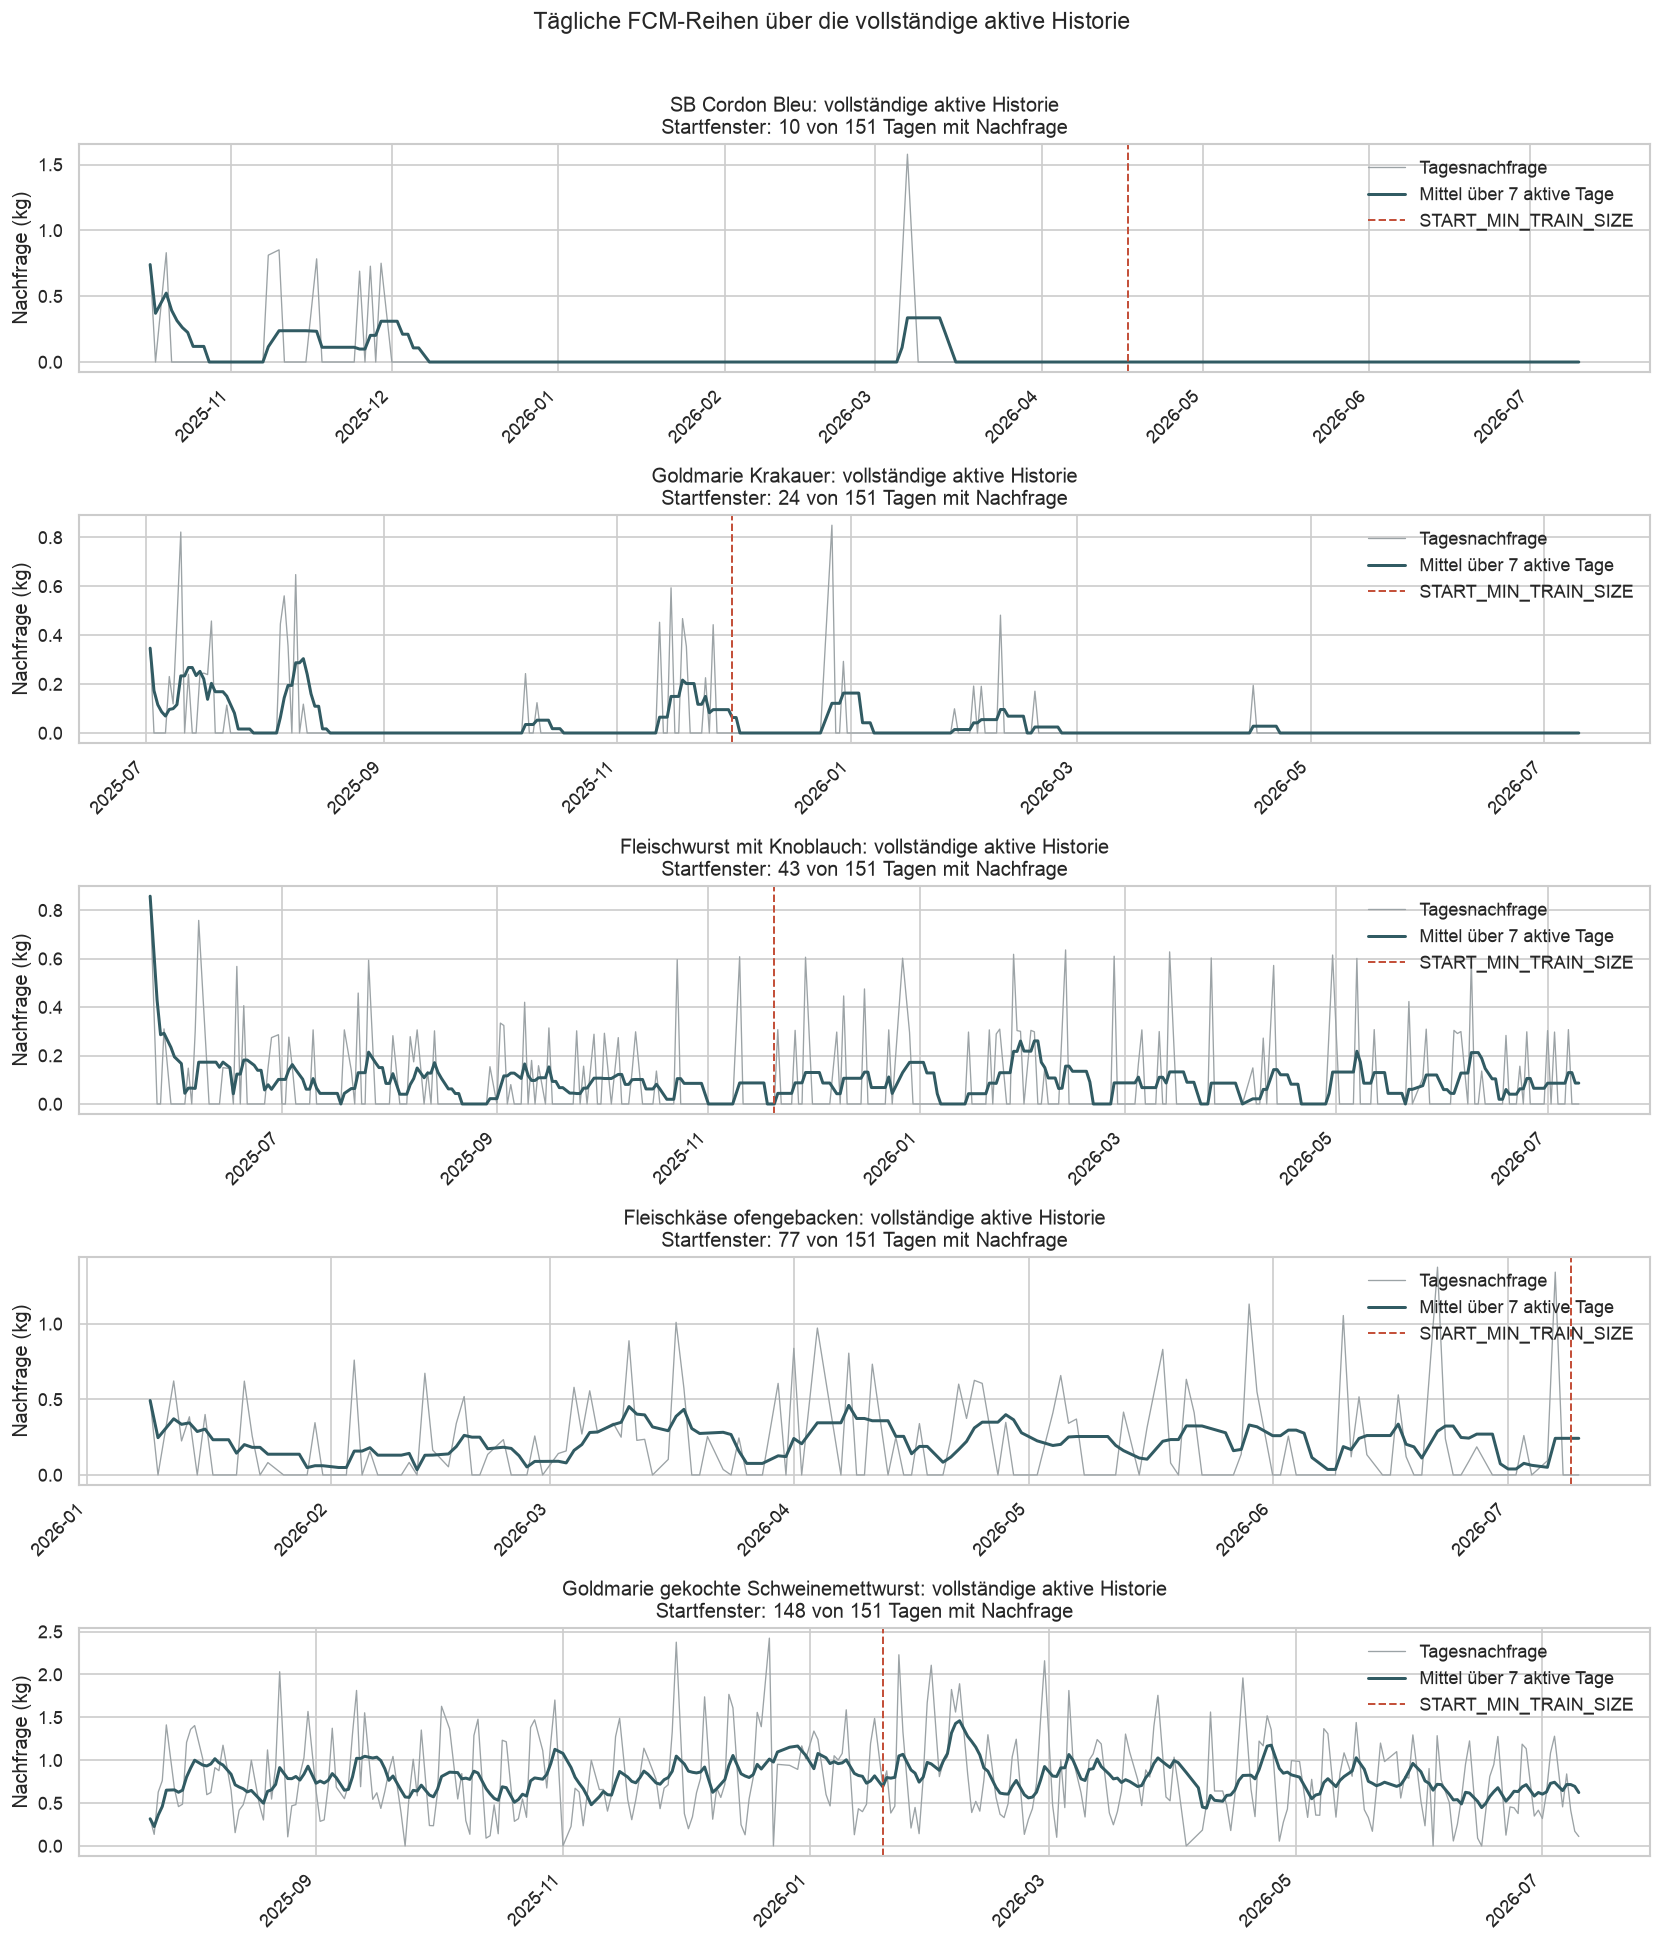

In [79]:
PATTERN_ESTIMABLE_SHARE = 0.50
PATTERN_CORRELATION_THRESHOLD = 0.70
PATTERN_FALLBACK_START_MIN_TRAIN_SIZE = 121
MIN_DEMAND_PERIODS_UNTIL_ORIGIN = 10
PATTERN_WINDOW_CANDIDATES = [31, 61, 91, 121, 151, 181]
PATTERN_EXAMPLE_SERIES = 5

daily_fcm_periods = con.execute(
    f"""
    SELECT
        ARTIKEL_ID,
        MARKT_ID,
        CAST(DATE AS DATE) AS period,
        SUM(CAST(COALESCE({DEMAND_COL}, 0) AS DOUBLE)) AS demand
    FROM read_parquet(?)
    GROUP BY ARTIKEL_ID, MARKT_ID, period
    ORDER BY ARTIKEL_ID, MARKT_ID, period
    """,
    [str(DATASETS["daily"]["fcm"] / "*.parquet")],
).fetchdf()
daily_fcm_periods["active_day_number"] = (
    daily_fcm_periods.groupby(GROUP_COLS, observed=True).cumcount() + 1
)
daily_fcm_periods["weekday_number"] = pd.to_datetime(
    daily_fcm_periods["period"]
).dt.weekday
active_weekdays = sorted(daily_fcm_periods["weekday_number"].unique())
active_days_per_week = len(active_weekdays)
total_pattern_series = daily_fcm_periods.groupby(GROUP_COLS, observed=True).ngroups

min_later_active_days = active_days_per_week * 4
pattern_rows = []
for candidate in PATTERN_WINDOW_CANDIDATES:
    candidate_data = daily_fcm_periods[
        daily_fcm_periods["active_day_number"] <= candidate
    ]
    later_data = daily_fcm_periods[
        daily_fcm_periods["active_day_number"] > candidate
    ]
    candidate_metrics = (
        candidate_data.groupby(GROUP_COLS, observed=True)
        .agg(
            active_days=("period", "size"),
            demand_days=("demand", lambda demand: (demand > 0).sum()),
        )
    )
    estimable_keys = candidate_metrics[
        (candidate_metrics["active_days"] == candidate)
        & (candidate_metrics["demand_days"] >= MIN_DEMAND_PERIODS_UNTIL_ORIGIN)
    ].index
    later_metrics = later_data.groupby(GROUP_COLS, observed=True).agg(
        later_active_days=("period", "size")
    )
    comparable_keys = [
        series_key for series_key in estimable_keys
        if series_key in later_metrics.index
        and later_metrics.loc[series_key, "later_active_days"] >= min_later_active_days
    ]
    candidate_profiles = (
        candidate_data.groupby([*GROUP_COLS, "weekday_number"], observed=True)["demand"]
        .mean()
        .unstack(fill_value=0)
        .reindex(columns=active_weekdays, fill_value=0)
    )
    later_profiles = (
        later_data.groupby([*GROUP_COLS, "weekday_number"], observed=True)["demand"]
        .mean()
        .unstack(fill_value=0)
        .reindex(columns=active_weekdays, fill_value=0)
    )
    profile_correlations = []
    for series_key in comparable_keys:
        candidate_profile = candidate_profiles.loc[series_key].to_numpy(dtype=float)
        later_profile = later_profiles.loc[series_key].to_numpy(dtype=float)
        if candidate_profile.std() > 0 and later_profile.std() > 0:
            profile_correlations.append(np.corrcoef(candidate_profile, later_profile)[0, 1])
    estimable_series = len(estimable_keys)
    pattern_rows.append({
        "aktive_tage": candidate,
        "schaetzbare_reihen": estimable_series,
        "reihen_mit_spaeterem_profil": len(comparable_keys),
        "anteil_schaetzbar": estimable_series / total_pattern_series,
        "mediane_korrelation_mit_spaeter": (
            float(np.nanmedian(profile_correlations)) if profile_correlations else np.nan
        ),
    })

pattern_window_results = pd.DataFrame(pattern_rows)
display(pattern_window_results.style.format({
    "anteil_schaetzbar": "{:.1%}",
    "mediane_korrelation_mit_spaeter": "{:.2f}",
}))
pattern_candidates = pattern_window_results[
    (pattern_window_results["anteil_schaetzbar"] >= PATTERN_ESTIMABLE_SHARE)
    & (pattern_window_results["mediane_korrelation_mit_spaeter"] >= PATTERN_CORRELATION_THRESHOLD)
]
if pattern_candidates.empty:
    suggested_start_min_train_size = PATTERN_FALLBACK_START_MIN_TRAIN_SIZE
    print("Kein Kandidat erfüllt beide Kriterien; 121 aktive Tage bleiben der konservative Startwert.")
else:
    suggested_start_min_train_size = int(pattern_candidates.iloc[0]["aktive_tage"])
print(f"Vorgeschlagener START_MIN_TRAIN_SIZE: {suggested_start_min_train_size} aktive Tage.")

start_window_data = daily_fcm_periods[
    daily_fcm_periods["active_day_number"] <= suggested_start_min_train_size
]
start_window_survivors = (
    start_window_data.groupby(GROUP_COLS, observed=True)
    .agg(
        window_active_days=("period", "size"),
        window_demand_days=("demand", lambda demand: (demand > 0).sum()),
    )
    .reset_index()
)
start_window_survivors = start_window_survivors[
    (start_window_survivors["window_active_days"] == suggested_start_min_train_size)
    & (start_window_survivors["window_demand_days"] >= MIN_DEMAND_PERIODS_UNTIL_ORIGIN)
].copy()
start_window_survivors["window_demand_day_share"] = (
    start_window_survivors["window_demand_days"]
    / start_window_survivors["window_active_days"]
)
start_window_survivors = start_window_survivors.sort_values(
    "window_demand_day_share"
).reset_index(drop=True)
if len(start_window_survivors) < PATTERN_EXAMPLE_SERIES:
    raise RuntimeError(f"Für die Musterdiagramme werden mindestens {PATTERN_EXAMPLE_SERIES} überlebende Reihen benötigt.")
pattern_positions = np.linspace(0, len(start_window_survivors) - 1, PATTERN_EXAMPLE_SERIES, dtype=int)
pattern_examples = start_window_survivors.iloc[pattern_positions].copy()
pattern_product_names = con.execute(
    """
    SELECT ARTIKEL_ID, ANY_VALUE(ARTIKEL_BEZ) AS ARTIKEL_BEZ
    FROM read_parquet(?)
    GROUP BY ARTIKEL_ID
    """,
    [str(DATASETS["daily"]["fcm"] / "*.parquet")],
).fetchdf()
pattern_examples = pattern_examples.merge(pattern_product_names, on="ARTIKEL_ID", how="left")

fig, axes = plt.subplots(len(pattern_examples), 1, figsize=(14, 3.2 * len(pattern_examples)), squeeze=False)
for row, product in pattern_examples.reset_index(drop=True).iterrows():
    series = daily_fcm_periods[
        (daily_fcm_periods["ARTIKEL_ID"] == product["ARTIKEL_ID"])
        & (daily_fcm_periods["MARKT_ID"] == product["MARKT_ID"])
    ].sort_values("period").copy()
    series["wochenmittel"] = series["demand"].rolling(
        active_days_per_week, min_periods=1
    ).mean()
    ax = axes[row, 0]
    start_window_end = series.loc[
        series["active_day_number"] == suggested_start_min_train_size, "period"
    ].iloc[0]
    ax.plot(series["period"], series["demand"], color="#9ca3a6", linewidth=0.8, label="Tagesnachfrage")
    ax.plot(series["period"], series["wochenmittel"], color="#315b63", linewidth=1.8, label=f"Mittel über {active_days_per_week} aktive Tage")
    ax.axvline(
        start_window_end,
        color="#c4513b",
        linestyle="--",
        linewidth=1.2,
        label="START_MIN_TRAIN_SIZE",
    )
    product_name = product["ARTIKEL_BEZ"] if pd.notna(product["ARTIKEL_BEZ"]) else "Unbekanntes Produkt"
    ax.set_title(
        f"{product_name}: vollständige aktive Historie\n"
        f"Startfenster: {int(product['window_demand_days'])} von "
        f"{suggested_start_min_train_size} Tagen mit Nachfrage"
    )
    ax.set_ylabel("Nachfrage (kg)")
    ax.tick_params(axis="x", labelrotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")
    ax.legend(loc="upper right", frameon=False)
fig.suptitle("Tägliche FCM-Reihen über die vollständige aktive Historie", fontsize=14, y=1.01)
fig.tight_layout()
figure_buffer = BytesIO()
fig.savefig(figure_buffer, format="png", dpi=120, bbox_inches="tight")
display(Image(data=figure_buffer.getvalue()))
plt.close(fig)


## Daily FCM: Selecting `DEFAULT_MIN_TRAIN_SIZE` for ADI/CV2 clustering and Modelling

This cell tests the starting window suggested by the preceding pattern analysis. It finds the smallest first training window that makes ADI and CV2 estimable for at least 50% of the daily FCM product-store series. Active days are observed rows for a series, not calendar days. A series is estimable only when it has the complete training window and at least the notebook-level `MIN_DEMAND_PERIODS_UNTIL_ORIGIN` days with positive demand inside that window. If more than 50% of all series are filtered out, the window is expanded by 10 active days and tested again. The selected value is the first window that meets the 50% rule.


In [80]:
START_MIN_TRAIN_SIZE = suggested_start_min_train_size
TRAIN_SIZE_STEP = 10
MAX_FILTERED_SHARE = 0.50

total_series = daily_fcm_periods.groupby(GROUP_COLS, observed=True).ngroups
max_active_days = int(daily_fcm_periods["active_day_number"].max())

def evaluate_min_train_size(min_train_size):
    first_window = daily_fcm_periods[
        daily_fcm_periods["active_day_number"] <= min_train_size
    ]
    window_metrics = (
        first_window.groupby(GROUP_COLS, observed=True)
        .agg(
            active_days_in_window=("period", "size"),
            demand_periods_in_window=("demand", lambda demand: (demand > 0).sum()),
        )
        .reset_index()
    )
    window_metrics["has_full_window"] = (
        window_metrics["active_days_in_window"] == min_train_size
    )
    window_metrics["estimable"] = (
        window_metrics["has_full_window"]
        & (window_metrics["demand_periods_in_window"] >= MIN_DEMAND_PERIODS_UNTIL_ORIGIN)
    )

    estimable = int(window_metrics["estimable"].sum())
    filtered = total_series - estimable
    insufficient_history = int((~window_metrics["has_full_window"]).sum())
    insufficient_demand = int(
        (
            window_metrics["has_full_window"]
            & (window_metrics["demand_periods_in_window"] < MIN_DEMAND_PERIODS_UNTIL_ORIGIN)
        ).sum()
    )
    return {
        "min_train_size_active_days": min_train_size,
        "total_series": total_series,
        "estimable_series": estimable,
        "filtered_series": filtered,
        "filtered_share": filtered / total_series,
        "insufficient_history": insufficient_history,
        "fewer_than_min_demand_days": insufficient_demand,
    }

window_tests = []
candidate = START_MIN_TRAIN_SIZE
while candidate <= max_active_days:
    result = evaluate_min_train_size(candidate)
    window_tests.append(result)
    if result["filtered_share"] <= MAX_FILTERED_SHARE:
        break
    candidate += TRAIN_SIZE_STEP

window_results = pd.DataFrame(window_tests)
display(window_results.style.format({"filtered_share": "{:.1%}"}))

acceptable = window_results[window_results["filtered_share"] <= MAX_FILTERED_SHARE]
if acceptable.empty:
    print(
        f"No tested window retained at least {1 - MAX_FILTERED_SHARE:.0%} of all series. "
        "The demand-period threshold or series scope must be reconsidered."
    )
else:
    selected_min_train_size = int(acceptable.iloc[0]["min_train_size_active_days"])
    selected_estimable_series = int(acceptable.iloc[0]["estimable_series"])
    print(
        f"Selected DEFAULT_MIN_TRAIN_SIZE: {selected_min_train_size} active days; "
        f"{selected_estimable_series} of {total_series} series are estimable."
    )


,min_train_size_active_days,total_series,estimable_series,filtered_series,filtered_share,insufficient_history,fewer_than_min_demand_days
0,151,2092,1574,518,24.8%,463,55


Selected DEFAULT_MIN_TRAIN_SIZE: 151 active days; 1574 of 2092 series are estimable.


### Repräsentative Produkte aus bis zu zwei Filialen

Die Darstellung verwendet höchstens zwei Filialen mit jeweils drei geeigneten Produkten. Für jedes Produkt steht links die tägliche Nachfrage und rechts die mittlere Nachfrage je Wochentag. Eine Filiale ergibt damit drei Produktzeilen mit jeweils zwei Diagrammen, also sechs Diagramme. Zwei Filialen ergeben sechs Produktzeilen und insgesamt zwölf Diagramme. Pro Filiale werden Produkte mit niedrigem, mittlerem und hohem Nachfragetageanteil ausgewählt. Jedes Produkt besitzt alle `START_MIN_TRAIN_SIZE` aktiven Tage und darin mindestens die konfigurierte Mindestanzahl an Tagen mit positiver Nachfrage. Gepunktete Linien markieren Kalenderwochen.

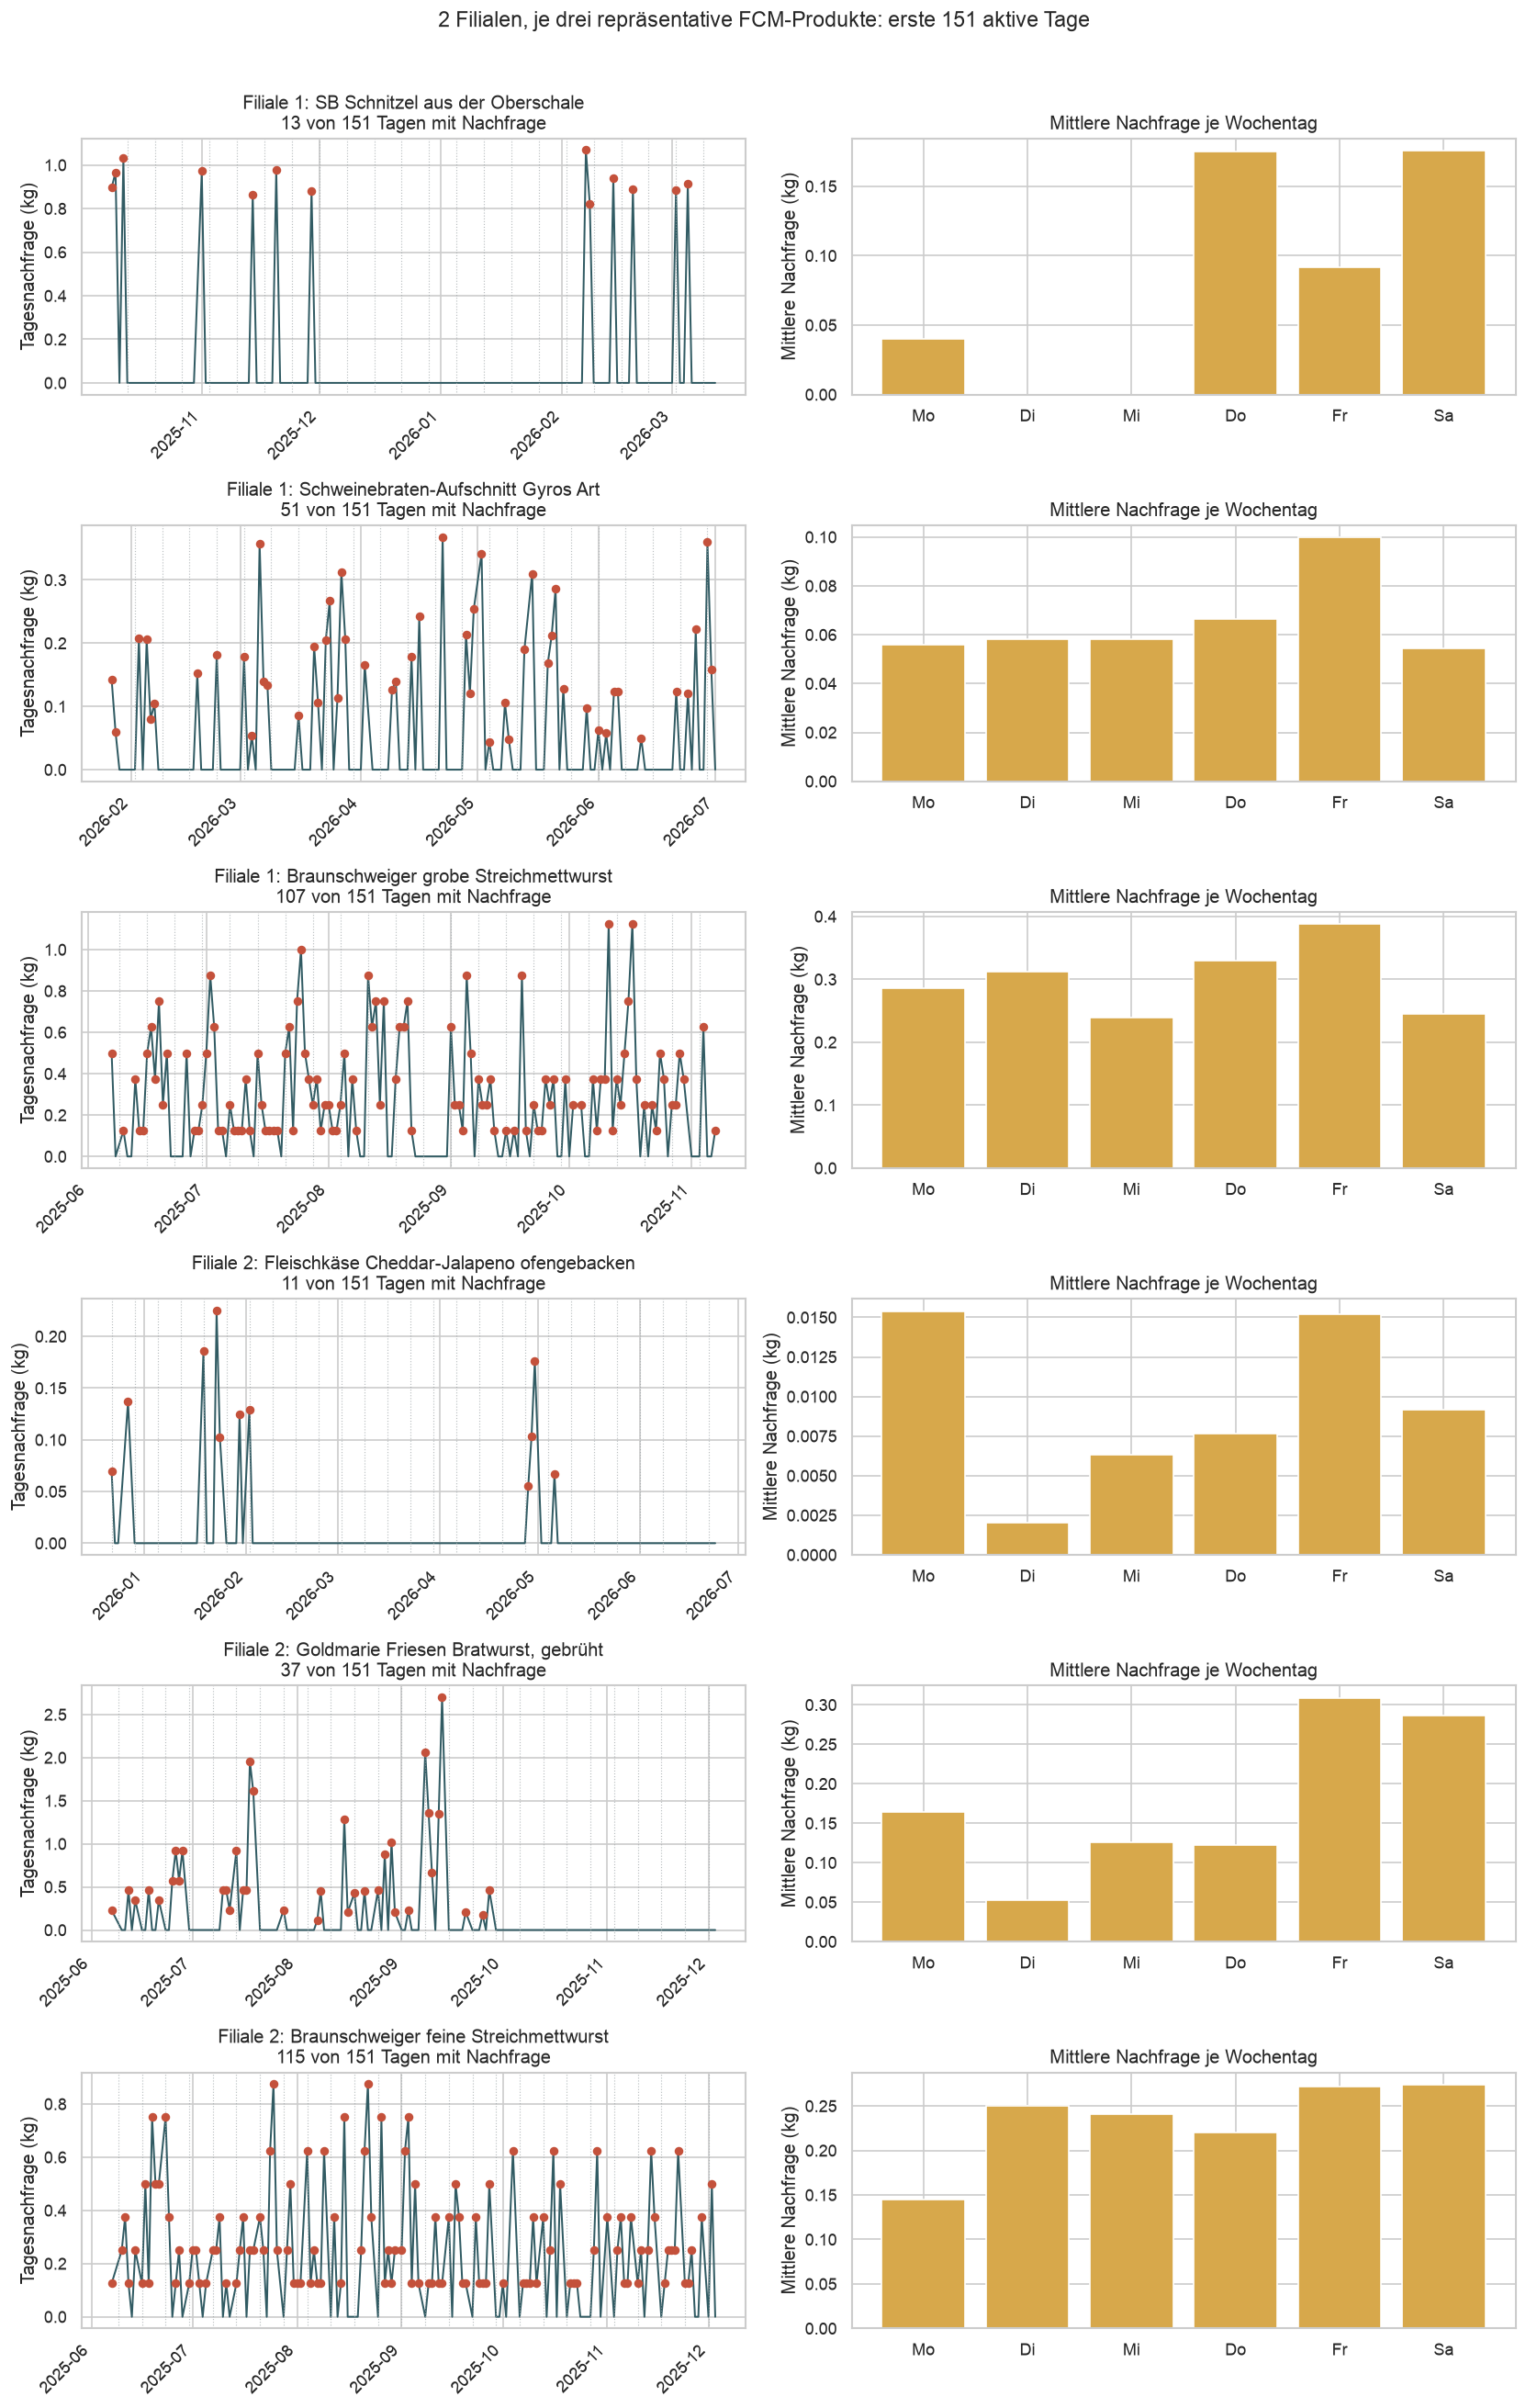

In [81]:
if acceptable.empty:
    raise RuntimeError("Representative products require an accepted training window.")

plot_window_size = START_MIN_TRAIN_SIZE
selected_window = daily_fcm_periods[
    daily_fcm_periods["active_day_number"] <= plot_window_size
].copy()
survivor_summary = (
    selected_window.groupby(GROUP_COLS, observed=True)
    .agg(
        active_days=("period", "size"),
        demand_days=("demand", lambda demand: (demand > 0).sum()),
    )
    .reset_index()
)
survivor_summary = survivor_summary[
    (survivor_summary["active_days"] == plot_window_size)
    & (survivor_summary["demand_days"] >= MIN_DEMAND_PERIODS_UNTIL_ORIGIN)
].copy()
survivor_summary["demand_day_share"] = (
    survivor_summary["demand_days"] / survivor_summary["active_days"]
)
store_counts = survivor_summary.groupby("MARKT_ID", observed=True).size().sort_values(ascending=False)
eligible_stores = store_counts[store_counts >= 3].head(2)
if eligible_stores.empty:
    raise RuntimeError("Es wird mindestens eine Filiale mit drei geeigneten Produkten benötigt.")
selected_store_ids = eligible_stores.index.tolist()
representative_parts = []
for store_number, store_id in enumerate(selected_store_ids, start=1):
    store_survivors = (
        survivor_summary[survivor_summary["MARKT_ID"] == store_id]
        .sort_values("demand_day_share")
        .reset_index(drop=True)
    )
    representative_positions = np.linspace(0, len(store_survivors) - 1, 3, dtype=int)
    store_representatives = store_survivors.iloc[representative_positions].copy()
    store_representatives["store_number"] = store_number
    representative_parts.append(store_representatives)
representatives = pd.concat(representative_parts, ignore_index=True)
product_names = con.execute(
    """
    SELECT ARTIKEL_ID, ANY_VALUE(ARTIKEL_BEZ) AS ARTIKEL_BEZ
    FROM read_parquet(?)
    GROUP BY ARTIKEL_ID
    """,
    [str(DATASETS["daily"]["fcm"] / "*.parquet")],
).fetchdf()
representatives = representatives.merge(product_names, on="ARTIKEL_ID", how="left")

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
weekday_labels = ["Mo", "Di", "Mi", "Do", "Fr", "Sa"]
store_count = len(selected_store_ids)
product_rows = store_count * 3
fig, axes = plt.subplots(
    product_rows, 2, figsize=(14, 3.6 * product_rows), squeeze=False
)

for store_row, store_id in enumerate(selected_store_ids):
    store_products = representatives[representatives["MARKT_ID"] == store_id].reset_index(drop=True)
    for product_position, product in store_products.iterrows():
        series = selected_window[
            (selected_window["ARTIKEL_ID"] == product["ARTIKEL_ID"])
            & (selected_window["MARKT_ID"] == product["MARKT_ID"])
        ].sort_values("period").copy()
        series["weekday"] = pd.to_datetime(series["period"]).dt.day_name()
        plot_row = store_row * 3 + product_position
        ax_daily, ax_weekday = axes[plot_row]
        ax_daily.plot(series["period"], series["demand"], color="#315b63", linewidth=1.2)
        ax_daily.scatter(
            series.loc[series["demand"] > 0, "period"],
            series.loc[series["demand"] > 0, "demand"],
            color="#c4513b", s=22, zorder=3
        )
        for week_start in pd.date_range(series["period"].min(), series["period"].max(), freq="W-MON"):
            ax_daily.axvline(week_start, color="#9ca3a6", linestyle=":", linewidth=0.7, alpha=0.7)
        product_name = product["ARTIKEL_BEZ"] if pd.notna(product["ARTIKEL_BEZ"]) else "Unbekanntes Produkt"
        ax_daily.set_title(
            f"Filiale {store_row + 1}: {product_name}\n"
            f"{int(product['demand_days'])} von {plot_window_size} Tagen mit Nachfrage"
        )
        ax_daily.set_ylabel("Tagesnachfrage (kg)")
        ax_daily.tick_params(axis="x", labelrotation=45)
        plt.setp(ax_daily.get_xticklabels(), ha="right")

        weekday_mean = (
            series.groupby("weekday", observed=True)["demand"]
            .mean()
            .reindex(weekday_order, fill_value=0)
        )
        weekday_positions = np.arange(len(weekday_labels))
        ax_weekday.bar(weekday_positions, weekday_mean.values, color="#d7a84b")
        ax_weekday.set_xticks(weekday_positions, weekday_labels)
        ax_weekday.set_title("Mittlere Nachfrage je Wochentag")
        ax_weekday.set_ylabel("Mittlere Nachfrage (kg)")

store_label = "Filiale" if store_count == 1 else "Filialen"
fig.suptitle(
    f"{store_count} {store_label}, je drei repräsentative FCM-Produkte: "
    f"erste {plot_window_size} aktive Tage",
    fontsize=14, y=1.01
)
fig.tight_layout()
figure_buffer = BytesIO()
fig.savefig(figure_buffer, format="png", dpi=120, bbox_inches="tight")
display(Image(data=figure_buffer.getvalue()))
plt.close(fig)


# Weekly analysis

Weekly rows represent active weeks. The weekly data retains daily diagnostics, so this section reports both the share of weeks with demand and the share of active days with demand inside those weeks.


In [82]:
weekly = metrics[metrics["aggregation"] == "weekly"].copy()
weekly_overview = (weekly.groupby("dataset", observed=True).agg(series=("ARTIKEL_ID", "size"), stores=("MARKT_ID", "nunique"), products=("ARTIKEL_ID", "nunique"), active_weeks=("active_periods", "sum"), demand_weeks=("demand_periods", "sum"), zero_weeks=("zero_periods", "sum"), total_demand_kg=("total_demand", "sum"), demand_day_share=("demand_day_share", "mean")).reset_index())
weekly_overview["demand_week_share"] = weekly_overview["demand_weeks"] / weekly_overview["active_weeks"]
display(weekly_overview.style.format({"total_demand_kg":"{:,.1f}", "demand_day_share":"{:.1%}", "demand_week_share":"{:.1%}"}))


,dataset,series,stores,products,active_weeks,demand_weeks,zero_weeks,total_demand_kg,demand_day_share,demand_week_share
0,Weekly / Regular,152550,112,3570,28402150,8348691,20053459,"29,690,343.2",14.2%,29.4%
1,Weekly / Fcm,3571,106,48,132377,66601,65776,"104,810.7",25.4%,50.3%


,dataset,measure,p25,median,p75,p95
0,Weekly / Regular,active_periods,124.00,225.00,260.00,261.00
1,Weekly / Regular,demand_periods,4.00,16.00,73.00,247.00
2,Weekly / Regular,zero_periods,45.00,139.00,214.00,248.00
3,Weekly / Regular,demand_day_share,0.01,0.04,0.19,0.65
4,Weekly / Regular,demand_period_share,0.03,0.12,0.46,0.98
5,Weekly / Fcm,active_periods,24.00,42.00,51.00,62.00
6,Weekly / Fcm,demand_periods,3.00,12.00,27.00,58.00
7,Weekly / Fcm,zero_periods,3.00,15.00,31.00,45.00
8,Weekly / Fcm,demand_day_share,0.05,0.17,0.42,0.75
9,Weekly / Fcm,demand_period_share,0.15,0.46,0.86,1.00


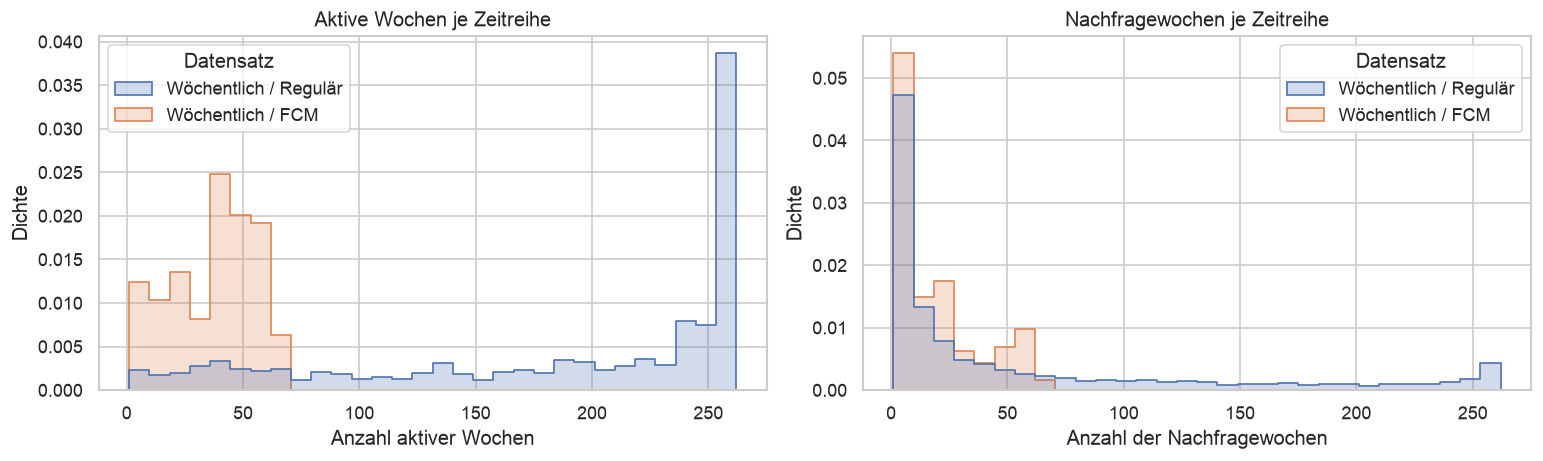

In [83]:
display(distribution_table(weekly, ["active_periods", "demand_periods", "zero_periods", "demand_day_share", "demand_period_share"]).style.format(quantile_format))
weekly_plot = weekly.copy()
weekly_plot["Datensatz"] = weekly_plot["dataset"].astype(str).replace({"Weekly / Regular": "Wöchentlich / Regulär", "Weekly / Fcm": "Wöchentlich / FCM"})
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=weekly_plot, x="active_periods", hue="Datensatz", bins=30, element="step", stat="density", common_norm=False, ax=axes[0])
sns.histplot(data=weekly_plot, x="demand_periods", hue="Datensatz", bins=30, element="step", stat="density", common_norm=False, ax=axes[1])
axes[0].set(title="Aktive Wochen je Zeitreihe", xlabel="Anzahl aktiver Wochen", ylabel="Dichte")
axes[1].set(title="Nachfragewochen je Zeitreihe", xlabel="Anzahl der Nachfragewochen", ylabel="Dichte")
plt.tight_layout()
figure_buffer = BytesIO()
fig.savefig(figure_buffer, format="png", dpi=120, bbox_inches="tight")
display(Image(data=figure_buffer.getvalue()))
plt.close(fig)


## Weekly binned count distributions

In [84]:
WEEK_BINS = [-1, 0, 1, 4, 8, 13, 26, 52, 104, 156, np.inf]
WEEK_LABELS = ["0", "1", "2-4", "5-8", "9-13", "14-26", "27-52", "53-104", "105-156", ">156"]
weekly_bins = binned_counts(weekly, ["active_periods", "demand_periods"], WEEK_BINS, WEEK_LABELS)
display(weekly_bins.pivot_table(index=["measure", "bin"], columns="dataset", values="share", observed=False).style.format("{:.1%}"))
for dataset, group in weekly.groupby("dataset", observed=True):
    print(dataset); display(top_store_products(group))


Weekly / Regular


,MARKT_ID,products_with_demand,total_demand,top_product_ids
0,1300001,2029,602885.557434,"316623, 316627, 317045"
1,1300002,1808,531175.319352,"316623, 316627, 317123"
2,1300005,1783,553978.165108,"316623, 317123, 316627"
3,1300024,1773,510279.490041,"316623, 316627, 317123"
4,1300027,1744,399619.229267,"316623, 316627, 316629"
5,1300008,1730,444042.426701,"316623, 316627, 317123"
6,1300004,1710,449348.708846,"316623, 317123, 316627"
7,1300021,1708,662394.180400,"316623, 317123, 292285"
8,1300025,1707,473156.700007,"316623, 317123, 316627"
9,1300020,1698,474568.494717,"316623, 316627, 317123"


Weekly / Fcm


,MARKT_ID,products_with_demand,total_demand,top_product_ids
0,1100009,42,1352.722200,"1382766, 1382765, 1382764"
1,1100015,42,1301.369100,"1376860, 1382768, 1382765"
2,1300028,42,1261.677275,"1382767, 1382766, 1382764"
3,1100056,42,681.271500,"1382768, 1406063, 1406590"
4,1100001,41,1703.151900,"1406587, 1382764, 1426349"
5,1100024,41,1307.694600,"1382768, 1406063, 1382766"
6,1100086,41,675.451800,"1406063, 1376860, 1406587"
7,1100036,41,662.090000,"1406063, 1406590, 1406587"
8,1100016,40,3829.165000,"1382766, 1382767, 1382788"
9,1100074,40,1410.907400,"1382766, 1382765, 1382768"


## Reading the results

Compare zero-period shares with demand-period shares to quantify intermittent demand within active observations. For weekly data, compare `demand_day_share` with `demand_week_share` to see how weekly aggregation hides daily zero-sales periods. The store tables rank stores by the number of products with positive demand and include the top product IDs by total demand.
